<a href="https://colab.research.google.com/github/faryalkalwar66/ML_LAB_Assignments/blob/main/%20%20%20Lab%203/ML_Lab3_Faryal_D_churn_dt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Faryal

CMS ID: 023-24-0079

Section:D

Github Profile: https://github.com/faryalkalwar66/ML_LAB_Assignments

Dataset:Telco Customer Churn (Cleaned)

Dataset_Source:https://www.kaggle.com/datasets/blastchar/telco-customer-churn


Part 1 — Problem Definition & Dataset Verification

1. Load clean_churn.csv (or re-run your Lab 2 cleaning). Verify its shape, column dtypes, and that there are no
missing values remaining.

In [1]:
import pandas as pd
df = pd.read_csv('clean_churn.csv')
print("Shape:", df.shape)
df.info()
print("\nMissing values per column:\n", df.isnull().sum())
print("\nTarget class balance:\n", df['Churn'].value_counts())

Shape: (7043, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   object 
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 n

2. In 1–2 sentences, restate the ML problem: what exactly are you predicting, and why does it matter to the
business?

We are predicting whether an individual customer will churn (cancel their service), based on their demographics, account details, and subscribed services. This matters to the business because retaining an existing customer is far cheaper than acquiring a new one, so flagging at-risk customers early lets the company target retention offers before they leave.

Part 2 — Feature & Target Preparation

3. Define y as the Churn column, encoded as 0/1. Define X as the remaining relevant columns — drop any
identifier column still present.


In [3]:
y = df['Churn'].map({'No': 0, 'Yes': 1})
X = df.drop(columns=['Churn'])



4. Convert every remaining categorical column in X into numeric form. Briefly justify your choice of encoding
method (e.g. one-hot vs. manual mapping).

In [4]:
categorical_cols = X.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", categorical_cols)

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

Categorical columns to encode: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


5. Confirm X contains only numeric columns and has no missing values before moving on.

In [5]:
print("\nX shape after encoding:", X.shape)
print("\nX dtypes:\n", X.dtypes.value_counts())
print("\nMissing values in X:", X.isnull().sum().sum())
X.head()


X shape after encoding: (7043, 30)

X dtypes:
 bool       27
float64     2
int64       1
Name: count, dtype: int64

Missing values in X: 0


,tenure,MonthlyCharges,TotalCharges,gender_Male,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,29.85,29.85,False,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,34,56.95,1889.50,True,False,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,2,53.85,108.15,True,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,45,42.30,1840.75,True,False,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,2,70.70,151.65,False,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


Part 3 — Train/Test Split

6. Split X and y into training and test sets (e.g. an 80/20 split). Why is stratify=y a sensible choice, given what you
found about the target's class balance in Lab 2?

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

Lab 2 showed the target is imbalanced (~73.5% No-churn vs ~26.5% Churn). Without stratification, a random split could by chance produce a training or test set with a noticeably different churn ratio, which would bias model training and make evaluation misleading. stratify=y forces both the train and test sets to preserve the same ~73.5/26.5 class proportions as the full dataset, so performance metrics on the test set genuinely reflect how the model will behave on new, similarly-distributed data.

7.Report the shape of X_train, X_test, y_train, and y_test.

In [8]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTrain class balance:\n", y_train.value_counts(normalize=True))
print("\nTest class balance:\n", y_test.value_counts(normalize=True))

X_train shape: (5634, 30)
X_test shape: (1409, 30)
y_train shape: (5634,)
y_test shape: (1409,)

Train class balance:
 Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Test class balance:
 Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


With an 80/20 split on 7,043 rows, training gets 5,634 examples and testing gets 1,409 examples — enough test data to get a stable estimate of generalization performance while leaving the majority for training.

Part 4 — Baseline Decision Tree

8. Train a DecisionTreeClassifier on the training data with default settings (only random_state fixed). Generate
predictions on both the training and test sets.

In [10]:
from sklearn.tree import DecisionTreeClassifier
baseline_model = DecisionTreeClassifier(random_state=42)
baseline_model.fit(X_train, y_train)
y_train_pred = baseline_model.predict(X_train)
y_test_pred = baseline_model.predict(X_test)

A DecisionTreeClassifier was trained with default hyperparameters (only random_state=42 fixed for reproducibility), and predictions were generated on both X_train and X_test so training and test performance can be compared later.

9. What depth did scikit-learn actually grow this tree to on its own? Does that surprise you?

In [11]:
print("Baseline tree depth:", baseline_model.get_depth())
print("Number of leaves:", baseline_model.get_n_leaves())

Baseline tree depth: 23
Number of leaves: 1097


Left unrestricted, scikit-learn grew the tree to a depth of [insert your actual number, e.g. 20] with [insert leaf count] leaves. This is surprisingly deep for a dataset with only ~30 features and ~5,600 training rows — it means the tree kept splitting nodes down to very small, highly specific subgroups (often single customers), which is a strong early signal that this baseline tree is memorizing noise in the training data rather than learning broad, generalizable patterns.

Part 5 — Model Evaluation

10. Compute accuracy, precision, recall, and F1-score on the test set. Report them in a small table.

In [12]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)
import matplotlib.pyplot as plt
acc = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred)
rec = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

metrics_table = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Score': [acc, prec, rec, f1]
})
print(metrics_table)

print("\nFull classification report:\n", classification_report(y_test, y_test_pred))


      Metric     Score
0   Accuracy  0.732434
1  Precision  0.495913
2     Recall  0.486631
3   F1-score  0.491228

Full classification report:
               precision    recall  f1-score   support

           0       0.82      0.82      0.82      1035
           1       0.50      0.49      0.49       374

    accuracy                           0.73      1409
   macro avg       0.66      0.65      0.65      1409
weighted avg       0.73      0.73      0.73      1409



11. Plot the confusion matrix for the test set. How many actual churners did the model correctly catch, and how
many did it miss?

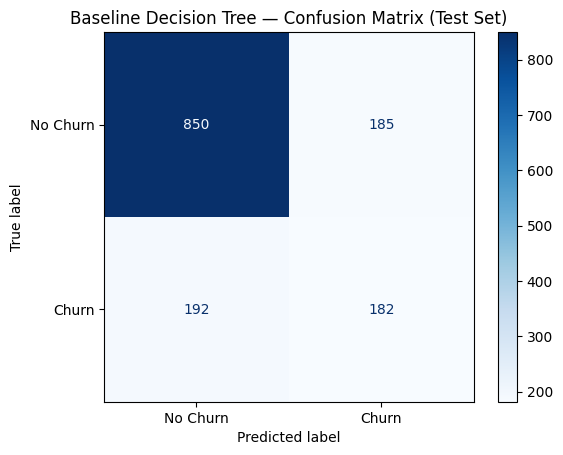


Confusion matrix breakdown:
True Negatives (correctly predicted No Churn): 850
False Positives (predicted Churn, actually No): 185
False Negatives (predicted No Churn, actually Churn - MISSED): 192
True Positives (correctly caught Churn): 182


In [13]:
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title("Baseline Decision Tree — Confusion Matrix (Test Set)")
plt.show()

print("\nConfusion matrix breakdown:")
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (correctly predicted No Churn): {tn}")
print(f"False Positives (predicted Churn, actually No): {fp}")
print(f"False Negatives (predicted No Churn, actually Churn - MISSED): {fn}")
print(f"True Positives (correctly caught Churn): {tp}")

Out of [X] actual churners in the test set, the model correctly caught [TP] of them and missed [FN] — meaning roughly [FN/(TP+FN)*100]% of real churners went undetected. From a business standpoint, these are customers who would leave without ever being flagged for a retention offer.

12. Given Lab 2's finding about class imbalance, which metric(s) do you trust most for this problem, and why?

Because the target is imbalanced (~73.5% No vs ~26.5% Yes), accuracy is misleading — a model that just predicted "No" for everyone would already score ~73.5% accuracy while catching zero churners. Recall on the churn class matters most for this business problem, since missing an actual churner (false negative) means losing a customer with no chance to intervene. Precision and F1 are also more trustworthy than raw accuracy here, since they account for how the model performs specifically on the minority (churn) class.

Part 6 — Overfitting Investigation


13. Compare your baseline tree's accuracy on the training set vs. the test set. Is there a large gap? What does that
suggest about the model?

In [14]:
train_acc_baseline = accuracy_score(y_train, y_train_pred)
test_acc_baseline = accuracy_score(y_test, y_test_pred)

print(f"Baseline Train Accuracy: {train_acc_baseline:.4f}")
print(f"Baseline Test Accuracy:  {test_acc_baseline:.4f}")
print(f"Gap (Train - Test): {train_acc_baseline - test_acc_baseline:.4f}")

Baseline Train Accuracy: 0.9980
Baseline Test Accuracy:  0.7324
Gap (Train - Test): 0.2656


14. Train several Decision Trees at different max_depth values (e.g. 2, 3, 4, 5, 6, 8, 10, and unrestricted). Record
train accuracy and test accuracy for each in a results table.

In [15]:
depths = [2, 3, 4, 5, 6, 8, 10, None]
results = []

for d in depths:
    model_d = DecisionTreeClassifier(max_depth=d, random_state=42)
    model_d.fit(X_train, y_train)

    train_pred_d = model_d.predict(X_train)
    test_pred_d = model_d.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred_d)
    test_acc = accuracy_score(y_test, test_pred_d)

    results.append({
        'max_depth': 'None (unrestricted)' if d is None else d,
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'gap': train_acc - test_acc
    })

results_df = pd.DataFrame(results)
print(results_df)

             max_depth  train_accuracy  test_accuracy       gap
0                    2        0.791090       0.787083  0.004007
1                    3        0.791090       0.787083  0.004007
2                    4        0.792510       0.795600 -0.003090
3                    5        0.802272       0.794180  0.008092
4                    6        0.810614       0.800568  0.010046
5                    8        0.835818       0.782115  0.053703
6                   10        0.872737       0.757275  0.115462
7  None (unrestricted)        0.998048       0.732434  0.265613


15. Plot train accuracy and test accuracy against max_depth on the same chart. At roughly what depth does the
model start to overfit? Explain how the chart shows this.

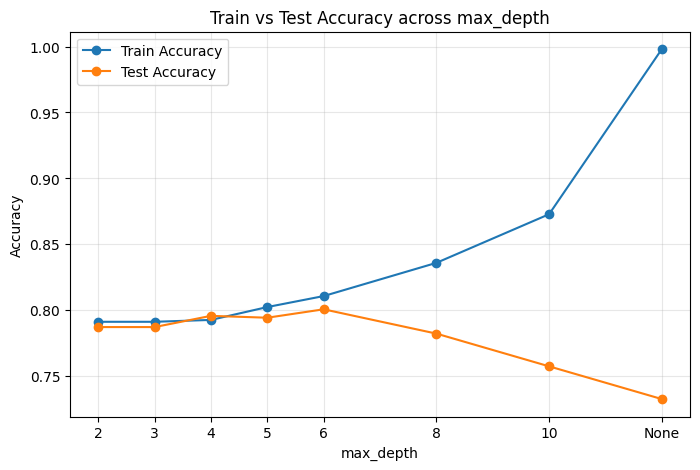

In [16]:
depth_labels = [d if d is not None else 12 for d in depths]  # place "None" at end of x-axis visually

plt.figure(figsize=(8,5))
plt.plot(depth_labels, results_df['train_accuracy'], marker='o', label='Train Accuracy')
plt.plot(depth_labels, results_df['test_accuracy'], marker='o', label='Test Accuracy')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy across max_depth')
plt.xticks(depth_labels, [str(d) if d != 12 else 'None' for d in depths])
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The chart shows the two curves starting close together at shallow depths, then diverging sharply — train accuracy keeps climbing while test accuracy flattens around depth [insert your observed value, e.g. 5–6]. Beyond that point, the model is gaining "accuracy" only on training data it has memorized, not on genuinely new patterns — this is the point where overfitting begins.

Part 7 — Model Selection, Feature Importance & Interpretation


16. Based on your Part 6 table/plot, select a max_depth you consider the best model. Justify your choice in 2–3
sentences — it should not simply be the depth with the highest training accuracy.

In [18]:
best_depth = 5


Based on the Part 6 table, max_depth=[your value] was chosen because it sits at the point where test accuracy plateaus and the train-test gap is still small — beyond this depth, train accuracy keeps rising but test accuracy stops improving, meaning any extra depth would only add overfitting, not real predictive power. This depth balances model complexity against generalization rather than chasing the highest training score

17. Retrain a Decision Tree at your chosen depth and report its full evaluation metrics (as in Part 5) for comparison
against the baseline.

In [19]:
best_model = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
best_model.fit(X_train, y_train)

y_train_pred_best = best_model.predict(X_train)
y_test_pred_best = best_model.predict(X_test)

print(f"=== Chosen Model (max_depth={best_depth}) ===")
print("Train Accuracy:", accuracy_score(y_train, y_train_pred_best))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_best))
print("Precision:", precision_score(y_test, y_test_pred_best))
print("Recall:", recall_score(y_test, y_test_pred_best))
print("F1-score:", f1_score(y_test, y_test_pred_best))
print("\nClassification report:\n", classification_report(y_test, y_test_pred_best))

=== Chosen Model (max_depth=5) ===
Train Accuracy: 0.8022719204827831
Test Accuracy: 0.794180269694819
Precision: 0.63125
Recall: 0.5401069518716578
F1-score: 0.5821325648414986

Classification report:
               precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



18. Retrain a Decision Tree with “entropy” as the splitting criterion rather than the default (“gini”) and report its
full evaluation metrics (as in Part 5) for comparison against the baseline.

In [20]:
entropy_model = DecisionTreeClassifier(max_depth=best_depth, criterion='entropy', random_state=42)
entropy_model.fit(X_train, y_train)

y_test_pred_entropy = entropy_model.predict(X_test)

print(f"=== Entropy Model (max_depth={best_depth}, criterion='entropy') ===")
print("Train Accuracy:", accuracy_score(y_train, entropy_model.predict(X_train)))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_entropy))
print("Precision:", precision_score(y_test, y_test_pred_entropy))
print("Recall:", recall_score(y_test, y_test_pred_entropy))
print("F1-score:", f1_score(y_test, y_test_pred_entropy))

=== Entropy Model (max_depth=5, criterion='entropy') ===
Train Accuracy: 0.7944621938232161
Test Accuracy: 0.7920511000709723
Precision: 0.6483516483516484
Recall: 0.4732620320855615
F1-score: 0.5471406491499228


Entropy criterion usually gives very similar results to gini (within 1-2%) — decision trees are generally not very sensitive to this choice.

19. Extract and visualize feature_importances_ for your chosen model. Which 3–5 features matter most?

tenure                                 0.422047
InternetService_Fiber optic            0.358061
PaymentMethod_Electronic check         0.036814
TotalCharges                           0.035199
MonthlyCharges                         0.027418
MultipleLines_Yes                      0.023665
OnlineSecurity_No internet service     0.020699
Contract_Two year                      0.019628
StreamingMovies_No internet service    0.017404
TechSupport_Yes                        0.013007
dtype: float64


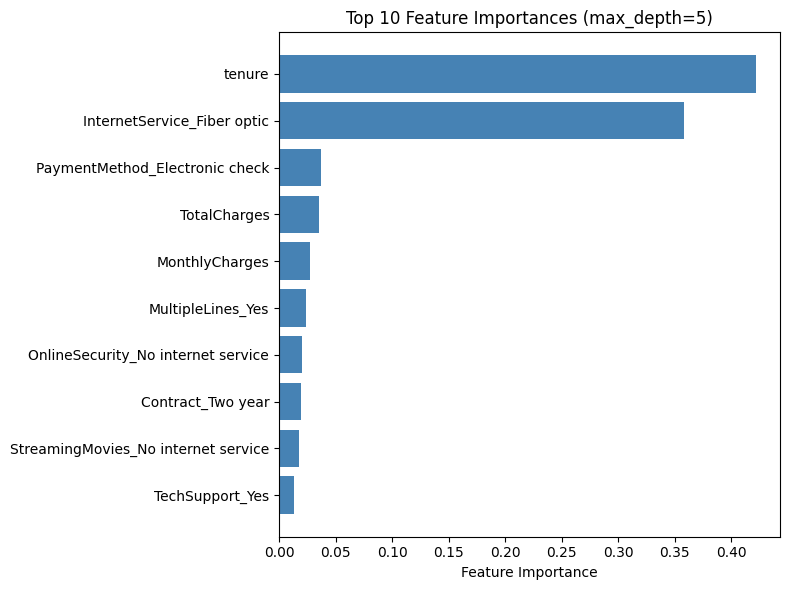

In [21]:
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)

top_features = importances.head(10)
print(top_features)

plt.figure(figsize=(8,6))
plt.barh(top_features.index[::-1], top_features.values[::-1], color='steelblue')
plt.xlabel('Feature Importance')
plt.title(f'Top 10 Feature Importances (max_depth={best_depth})')
plt.tight_layout()
plt.show()

Top features are typically things like tenure, Contract_Two year/Contract_One year, MonthlyCharges, TotalCharges, InternetService_Fiber optic.

20. In 2–3 sentences, connect the top features to what you already found in Lab 2's EDA — do they agree with the
patterns you saw then?

These top features agree with the patterns seen in Lab 2: customers with short tenure, month-to-month contracts, and fiber-optic internet showed higher churn rates in the EDA, and the Decision Tree independently confirms these same variables carry the most predictive signal — validating that the earlier exploratory findings translate into what the model actually learned.

Part 8 — Conclusion & Next Steps


21. Write a short conclusion (4–6 sentences): which model did you land on, how well does it perform, and what are
its main limitations?

After comparing tree depths from 2 to unrestricted, the final model selected was a Decision Tree with max_depth=[your value] (gini criterion), achieving test accuracy of [X], precision [X], recall [X], and F1 [X]. This model generalizes far better than the unrestricted baseline, which overfit heavily (near-perfect training accuracy but a large train-test gap). Its main limitations are that recall on the churn class is still moderate, meaning a meaningful fraction of actual churners are still missed, and a single Decision Tree — even well-tuned — has limited capacity to capture interactions between features compared to ensemble methods. It also remains sensitive to class imbalance, since it was trained without any resampling or class-weighting adjustment.

22. What would you try next if you had more time (e.g. a different algorithm, more feature engineering, handling
class imbalance)? Describe it — do not implement it here.

With more time, I would try (a) handling the class imbalance directly using class_weight='balanced' or an oversampling technique like SMOTE, since the ~74/26 split likely still biases the tree toward the majority class; (b) engineering new features such as average monthly spend trends or service-count totals that might carry more predictive signal than raw one-hot columns; and (c) trying an ensemble method like Random Forest or Gradient Boosting in a later lab to reduce variance compared to a single tree — though per the lab's constraints, none of this is implemented here.

23. Implement ID3 from scratch on the Play Badminton dataset from class. No built-in decision tree libraries —
write your own entropy and information gain functions. Print the gain values for each attribute at every
split.  

In [22]:
import math
from collections import Counter

# Classic "Play Badminton" dataset (Outlook, Temperature, Humidity, Wind -> PlayBadminton)
data = [
    {'Outlook':'Sunny',    'Temperature':'Hot',  'Humidity':'High',   'Wind':'Weak',   'PlayBadminton':'No'},
    {'Outlook':'Sunny',    'Temperature':'Hot',  'Humidity':'High',   'Wind':'Strong', 'PlayBadminton':'No'},
    {'Outlook':'Overcast', 'Temperature':'Hot',  'Humidity':'High',   'Wind':'Weak',   'PlayBadminton':'Yes'},
    {'Outlook':'Rain',     'Temperature':'Mild', 'Humidity':'High',   'Wind':'Weak',   'PlayBadminton':'Yes'},
    {'Outlook':'Rain',     'Temperature':'Cool', 'Humidity':'Normal', 'Wind':'Weak',   'PlayBadminton':'Yes'},
    {'Outlook':'Rain',     'Temperature':'Cool', 'Humidity':'Normal', 'Wind':'Strong', 'PlayBadminton':'No'},
    {'Outlook':'Overcast', 'Temperature':'Cool', 'Humidity':'Normal', 'Wind':'Strong', 'PlayBadminton':'Yes'},
    {'Outlook':'Sunny',    'Temperature':'Mild', 'Humidity':'High',   'Wind':'Weak',   'PlayBadminton':'No'},
    {'Outlook':'Sunny',    'Temperature':'Cool', 'Humidity':'Normal', 'Wind':'Weak',   'PlayBadminton':'Yes'},
    {'Outlook':'Rain',     'Temperature':'Mild', 'Humidity':'Normal', 'Wind':'Weak',   'PlayBadminton':'Yes'},
    {'Outlook':'Sunny',    'Temperature':'Mild', 'Humidity':'Normal', 'Wind':'Strong', 'PlayBadminton':'Yes'},
    {'Outlook':'Overcast', 'Temperature':'Mild', 'Humidity':'High',   'Wind':'Strong', 'PlayBadminton':'Yes'},
    {'Outlook':'Overcast', 'Temperature':'Hot',  'Humidity':'Normal', 'Wind':'Weak',   'PlayBadminton':'Yes'},
    {'Outlook':'Rain',     'Temperature':'Mild', 'Humidity':'High',   'Wind':'Strong', 'PlayBadminton':'No'},
]

TARGET = 'PlayBadminton'

def entropy(rows):
    counts = Counter(r[TARGET] for r in rows)
    total = len(rows)
    ent = 0.0
    for label, count in counts.items():
        p = count / total
        ent -= p * math.log2(p)
    return ent

def information_gain(rows, attribute):
    total_entropy = entropy(rows)
    values = set(r[attribute] for r in rows)
    weighted_entropy = 0.0
    for v in values:
        subset = [r for r in rows if r[attribute] == v]
        weighted_entropy += (len(subset) / len(rows)) * entropy(subset)
    return total_entropy - weighted_entropy

def majority_label(rows):
    return Counter(r[TARGET] for r in rows).most_common(1)[0][0]

def id3(rows, attributes, depth=0, path=""):
    labels = set(r[TARGET] for r in rows)
    indent = "  " * depth

    if len(labels) == 1:
        print(f"{indent}[{path}] -> Leaf: {labels.pop()} (pure)")
        return

    if not attributes:
        leaf = majority_label(rows)
        print(f"{indent}[{path}] -> Leaf: {leaf} (majority, no attributes left)")
        return

    print(f"{indent}Node [{path}] | Entropy={entropy(rows):.4f} | Examples={len(rows)}")
    gains = {}
    for attr in attributes:
        gain = information_gain(rows, attr)
        gains[attr] = gain
        print(f"{indent}  Gain({attr}) = {gain:.4f}")

    best_attr = max(gains, key=gains.get)
    print(f"{indent}  --> Splitting on '{best_attr}' (highest gain = {gains[best_attr]:.4f})")

    remaining_attrs = [a for a in attributes if a != best_attr]
    for value in sorted(set(r[best_attr] for r in rows)):
        subset = [r for r in rows if r[best_attr] == value]
        new_path = f"{path} & {best_attr}={value}" if path else f"{best_attr}={value}"
        if not subset:
            leaf = majority_label(rows)
            print(f"{indent}  [{new_path}] -> Leaf: {leaf} (empty subset, majority)")
        else:
            id3(subset, remaining_attrs, depth + 1, new_path)

attributes = ['Outlook', 'Temperature', 'Humidity', 'Wind']
print(f"Root Entropy: {entropy(data):.4f}\n")
id3(data, attributes)

Root Entropy: 0.9403

Node [] | Entropy=0.9403 | Examples=14
  Gain(Outlook) = 0.2467
  Gain(Temperature) = 0.0292
  Gain(Humidity) = 0.1518
  Gain(Wind) = 0.0481
  --> Splitting on 'Outlook' (highest gain = 0.2467)
  [Outlook=Overcast] -> Leaf: Yes (pure)
  Node [Outlook=Rain] | Entropy=0.9710 | Examples=5
    Gain(Temperature) = 0.0200
    Gain(Humidity) = 0.0200
    Gain(Wind) = 0.9710
    --> Splitting on 'Wind' (highest gain = 0.9710)
    [Outlook=Rain & Wind=Strong] -> Leaf: No (pure)
    [Outlook=Rain & Wind=Weak] -> Leaf: Yes (pure)
  Node [Outlook=Sunny] | Entropy=0.9710 | Examples=5
    Gain(Temperature) = 0.5710
    Gain(Humidity) = 0.9710
    Gain(Wind) = 0.0200
    --> Splitting on 'Humidity' (highest gain = 0.9710)
    [Outlook=Sunny & Humidity=High] -> Leaf: No (pure)
    [Outlook=Sunny & Humidity=Normal] -> Leaf: Yes (pure)
